# Notebook 06 — Évaluation des Modèles de Machine Learning

**Présenté par**: Équipe BankAnalyzer  
**Dataset**: 46 702 transactions bancaires marocaines synthétiques  

Ce notebook constitue le **tableau de bord d'évaluation** pour le jury.  
Il évalue les trois modèles entraînés:

| Modèle | Algorithme | Tâche |
|---|---|---|
| 1. Classifieur | TF-IDF + Régression Logistique | Catégorisation automatique |
| 2. Détecteur | Isolation Forest | Détection d'anomalies |
| 3. Prédicteur | Random Forest | Prévision des dépenses |

> **Prérequis**: Exécuter les notebooks 04 et 05 avant ce notebook.

In [9]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_absolute_percentage_error, r2_score
)
import joblib

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

PROJECT_ROOT = Path.cwd().parent
DATA_DIR     = PROJECT_ROOT / 'data' / 'processed'
MODELS_STORE = PROJECT_ROOT / 'backend' / 'models_store'

print('Vérification des modèles:')
required = [
    'tfidf_vectorizer.pkl', 'lr_category_classifier.pkl',
    'isolation_forest.pkl', 'anomaly_label_encoder.pkl',
    'rf_expense_predictor.pkl', 'category_encoder.pkl',
]
all_ok = True
for f in required:
    exists = (MODELS_STORE / f).exists()
    if not exists:
        all_ok = False
    print(f'  {"OK" if exists else "MANQUANT":<8} {f}')
if not all_ok:
    print('\nERREUR: Exécuter notebooks 04 et 05 pour générer les modèles manquants.')

Vérification des modèles:
  OK       tfidf_vectorizer.pkl
  OK       lr_category_classifier.pkl
  OK       isolation_forest.pkl
  OK       anomaly_label_encoder.pkl
  OK       rf_expense_predictor.pkl
  OK       category_encoder.pkl


In [10]:
df = pd.read_csv(DATA_DIR / 'transactions_segmentees.csv', low_memory=False)
df = df.dropna(subset=['category', 'text_to_segment', 'amount', 'direction']).copy()
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['amount'] = pd.to_numeric(df['amount'], errors='coerce').abs()
df = df.dropna(subset=['amount'])
df['hour']       = pd.to_numeric(df.get('hour', 12), errors='coerce').fillna(12).astype(int)
df['is_weekend'] = df['transaction_date'].dt.dayofweek.isin([5, 6]).astype(int)
print(f'Dataset: {len(df):,} transactions, {df["category"].nunique()} catégories')

Dataset: 46,702 transactions, 11 catégories


---
## Section 1 — Classifieur TF-IDF + Régression Logistique

In [11]:
vectorizer = joblib.load(MODELS_STORE / 'tfidf_vectorizer.pkl')
classifier = joblib.load(MODELS_STORE / 'lr_category_classifier.pkl')

X_all = df['text_to_segment'].astype(str)
y_all = df['category']
_, X_test, _, y_test = train_test_split(X_all, y_all, test_size=0.20, random_state=42, stratify=y_all)

y_pred = classifier.predict(vectorizer.transform(X_test))
acc  = accuracy_score(y_test, y_pred)
f1_w = f1_score(y_test, y_pred, average='weighted')
f1_m = f1_score(y_test, y_pred, average='macro')

print('RÉSULTATS — TF-IDF + Régression Logistique')
print(f'  Accuracy       : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  F1 (weighted)  : {f1_w:.4f}')
print(f'  F1 (macro)     : {f1_m:.4f}')
print()
print(classification_report(y_test, y_pred, digits=4))

RÉSULTATS — TF-IDF + Régression Logistique
  Accuracy       : 1.0000  (100.00%)
  F1 (weighted)  : 1.0000
  F1 (macro)     : 1.0000

              precision    recall  f1-score   support

Alimentation     1.0000    1.0000    1.0000      1766
  E-commerce     1.0000    1.0000    1.0000       839
    Factures     1.0000    1.0000    1.0000       937
    Logement     1.0000    1.0000    1.0000       653
     Loisirs     1.0000    1.0000    1.0000       715
Retrait cash     1.0000    1.0000    1.0000       753
      Revenu     1.0000    1.0000    1.0000       518
       Santé     1.0000    1.0000    1.0000       642
    Shopping     1.0000    1.0000    1.0000       748
   Transport     1.0000    1.0000    1.0000      1420
      Voyage     1.0000    1.0000    1.0000       350

    accuracy                         1.0000      9341
   macro avg     1.0000    1.0000    1.0000      9341
weighted avg     1.0000    1.0000    1.0000      9341



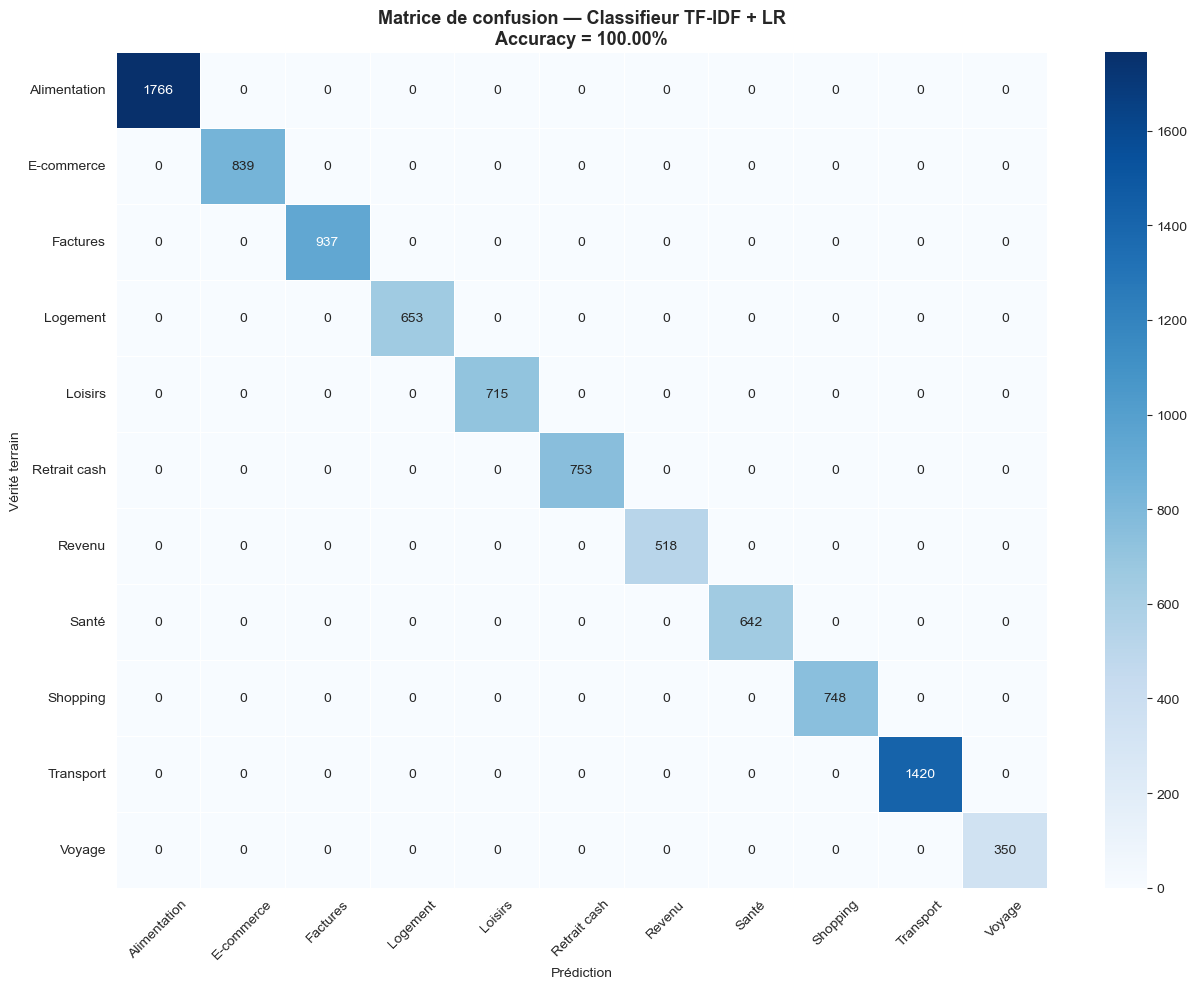

In [12]:
labels = list(classifier.classes_)
cm = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, linewidths=0.5, ax=ax)
ax.set_title(f'Matrice de confusion — Classifieur TF-IDF + LR\nAccuracy = {acc*100:.2f}%',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Prédiction')
ax.set_ylabel('Vérité terrain')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

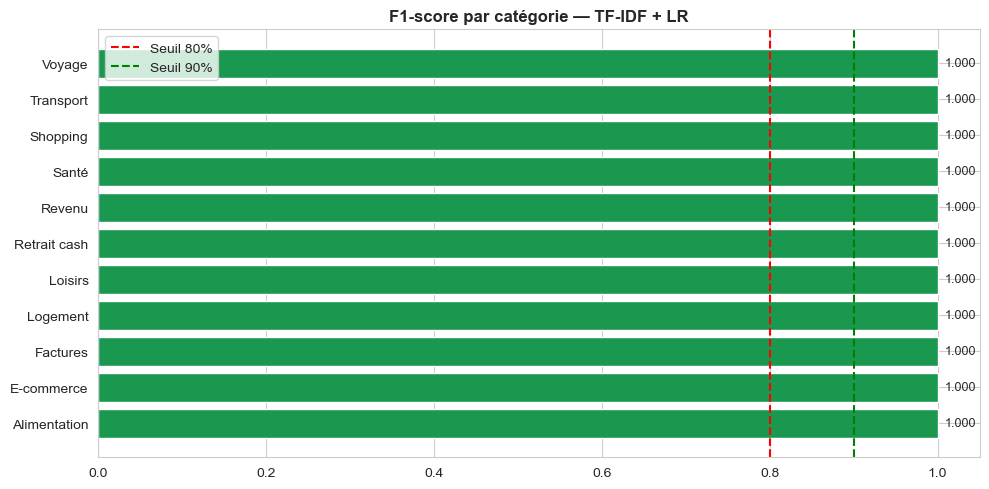

In [13]:
f1_per = f1_score(y_test, y_pred, labels=labels, average=None)
f1_df  = pd.DataFrame({'categorie': labels, 'F1': f1_per}).sort_values('F1')
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(f1_df['categorie'], f1_df['F1'],
        color=['#d73027' if v < 0.8 else '#fee090' if v < 0.9 else '#1a9850' for v in f1_df['F1']],
        edgecolor='white')
ax.axvline(0.80, color='red',   linestyle='--', linewidth=1.5, label='Seuil 80%')
ax.axvline(0.90, color='green', linestyle='--', linewidth=1.5, label='Seuil 90%')
ax.set_xlim(0, 1.05)
ax.set_title('F1-score par catégorie — TF-IDF + LR', fontweight='bold')
ax.legend()
for i, (_, row) in enumerate(f1_df.iterrows()):
    ax.text(row['F1'] + 0.008, i, f"{row['F1']:.3f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## Section 2 — Détection d'Anomalies (Isolation Forest)

In [14]:
iso_forest = joblib.load(MODELS_STORE / 'isolation_forest.pkl')
le_anomaly = joblib.load(MODELS_STORE / 'anomaly_label_encoder.pkl')

debits = df[df['direction'] == 'Debit'].copy()
known  = set(le_anomaly.classes_)
safe   = debits['category'].apply(lambda c: c if c in known else le_anomaly.classes_[0])
debits['cat_enc']       = le_anomaly.transform(safe)
X_anom                  = debits[['amount', 'hour', 'is_weekend', 'cat_enc']].values
debits['anomaly_label'] = iso_forest.predict(X_anom)
debits['anomaly_score'] = iso_forest.score_samples(X_anom)

n_anom = (debits['anomaly_label'] == -1).sum()
print(f'Transactions Debit  : {len(debits):,}')
print(f'Anomalies détectées : {n_anom:,} ({n_anom/len(debits)*100:.2f}%)')

Transactions Debit  : 45,607
Anomalies détectées : 2,281 (5.00%)


Taux anomalie par catégorie:
              total  anomalies   taux
category                             
Logement       3265       1315  40.28
Voyage         1750        556  31.77
Santé          3213        158   4.92
E-commerce     4193         89   2.12
Alimentation   8832         88   1.00
Retrait cash   3763         23   0.61
Transport      7100         34   0.48
Shopping       3738         15   0.40
Loisirs        3575          2   0.06
Factures       4684          1   0.02
Revenu         1494          0   0.00


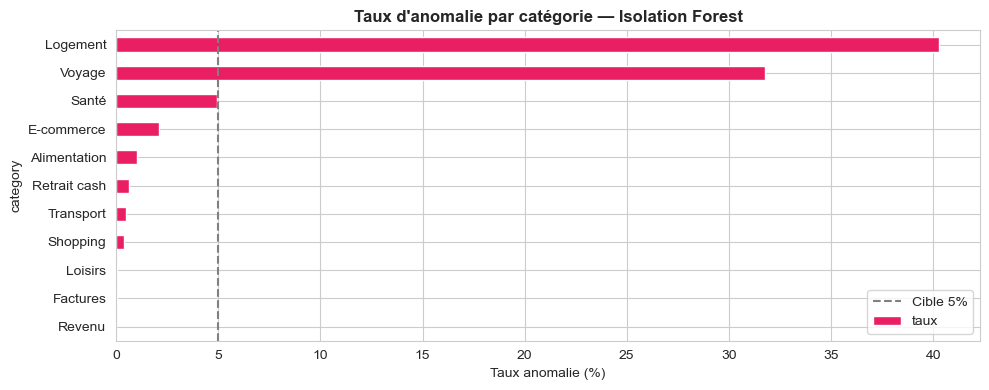

In [15]:
anom_stats = debits.groupby('category').agg(
    total=('amount', 'count'),
    anomalies=('anomaly_label', lambda x: (x == -1).sum()),
).assign(taux=lambda d: (d['anomalies'] / d['total'] * 100).round(2))

print('Taux anomalie par catégorie:')
print(anom_stats.sort_values('taux', ascending=False).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
anom_stats['taux'].sort_values().plot(kind='barh', ax=ax, color='#E91E63', edgecolor='white')
ax.axvline(5, color='gray', linestyle='--', label='Cible 5%')
ax.set_xlabel('Taux anomalie (%)')
ax.set_title('Taux d\'anomalie par catégorie — Isolation Forest', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 3 — Prédiction des Dépenses (Random Forest)

In [16]:
import sys
sys.path.insert(0, str(Path('..') / 'backend'))
from pipeline.prediction.trainer import train

df_train = pd.read_csv(DATA_DIR / 'transactions_segmentees.csv', low_memory=False)
df_train = df_train.dropna(subset=['category', 'amount', 'direction']).copy()
df_train['transaction_date'] = pd.to_datetime(df_train['transaction_date'])
df_train['amount'] = pd.to_numeric(df_train['amount'], errors='coerce').abs()
df_train = df_train.dropna(subset=['amount'])

print("Entraînement du modèle Random Forest...")
train(df_train)

rf_path  = MODELS_STORE / 'rf_expense_predictor.pkl'
enc_path = MODELS_STORE / 'category_encoder.pkl'
print(f"  rf_expense_predictor.pkl : {'OK' if rf_path.exists() else 'MANQUANT'}")
print(f"  category_encoder.pkl     : {'OK' if enc_path.exists() else 'MANQUANT'}")

Entraînement du modèle Random Forest...
  rf_expense_predictor.pkl : OK
  category_encoder.pkl     : OK


In [17]:
rf_model = joblib.load(MODELS_STORE / 'rf_expense_predictor.pkl')
le_cat   = joblib.load(MODELS_STORE / 'category_encoder.pkl')

deb = df[df['direction'] == 'Debit'].copy()
deb['period']     = deb['transaction_date'].dt.to_period('M')
deb['month']      = deb['transaction_date'].dt.month
deb['is_weekend'] = deb['transaction_date'].dt.dayofweek.isin([5, 6]).astype(int)

monthly = deb.groupby(['period', 'category']).agg(
    total_amount=('amount', 'sum'), avg_amount=('amount', 'mean'),
    transaction_count=('amount', 'count'), month=('month', 'first'),
    is_weekend_ratio=('is_weekend', 'mean')
).reset_index()
monthly['period_int'] = monthly['period'].apply(lambda p: p.year * 12 + p.month)

# Holdout: 3 derniers mois
periods = sorted(monthly['period'].unique())
test_periods = periods[-3:]
test_df = monthly[monthly['period'].isin(test_periods) & monthly['category'].isin(le_cat.classes_)].copy()
test_df['category_enc'] = le_cat.transform(test_df['category'])

FEAT = ['period_int', 'category_enc', 'month', 'transaction_count', 'avg_amount', 'is_weekend_ratio']
y_act  = test_df['total_amount'].values
y_pred_rf = rf_model.predict(test_df[FEAT].values)
test_df['predicted'] = y_pred_rf

mae  = mean_absolute_error(y_act, y_pred_rf)
mape = mean_absolute_percentage_error(y_act, y_pred_rf) * 100
r2   = r2_score(y_act, y_pred_rf)

print(f'Holdout: {test_periods[0]} → {test_periods[-1]}')
print(f'MAE  : {mae:,.0f} MAD')
print(f'MAPE : {mape:.1f}%')
print(f'R²   : {r2:.4f}')

Holdout: 2024-10 → 2024-12
MAE  : 1,478 MAD
MAPE : 2.8%
R²   : 0.9988


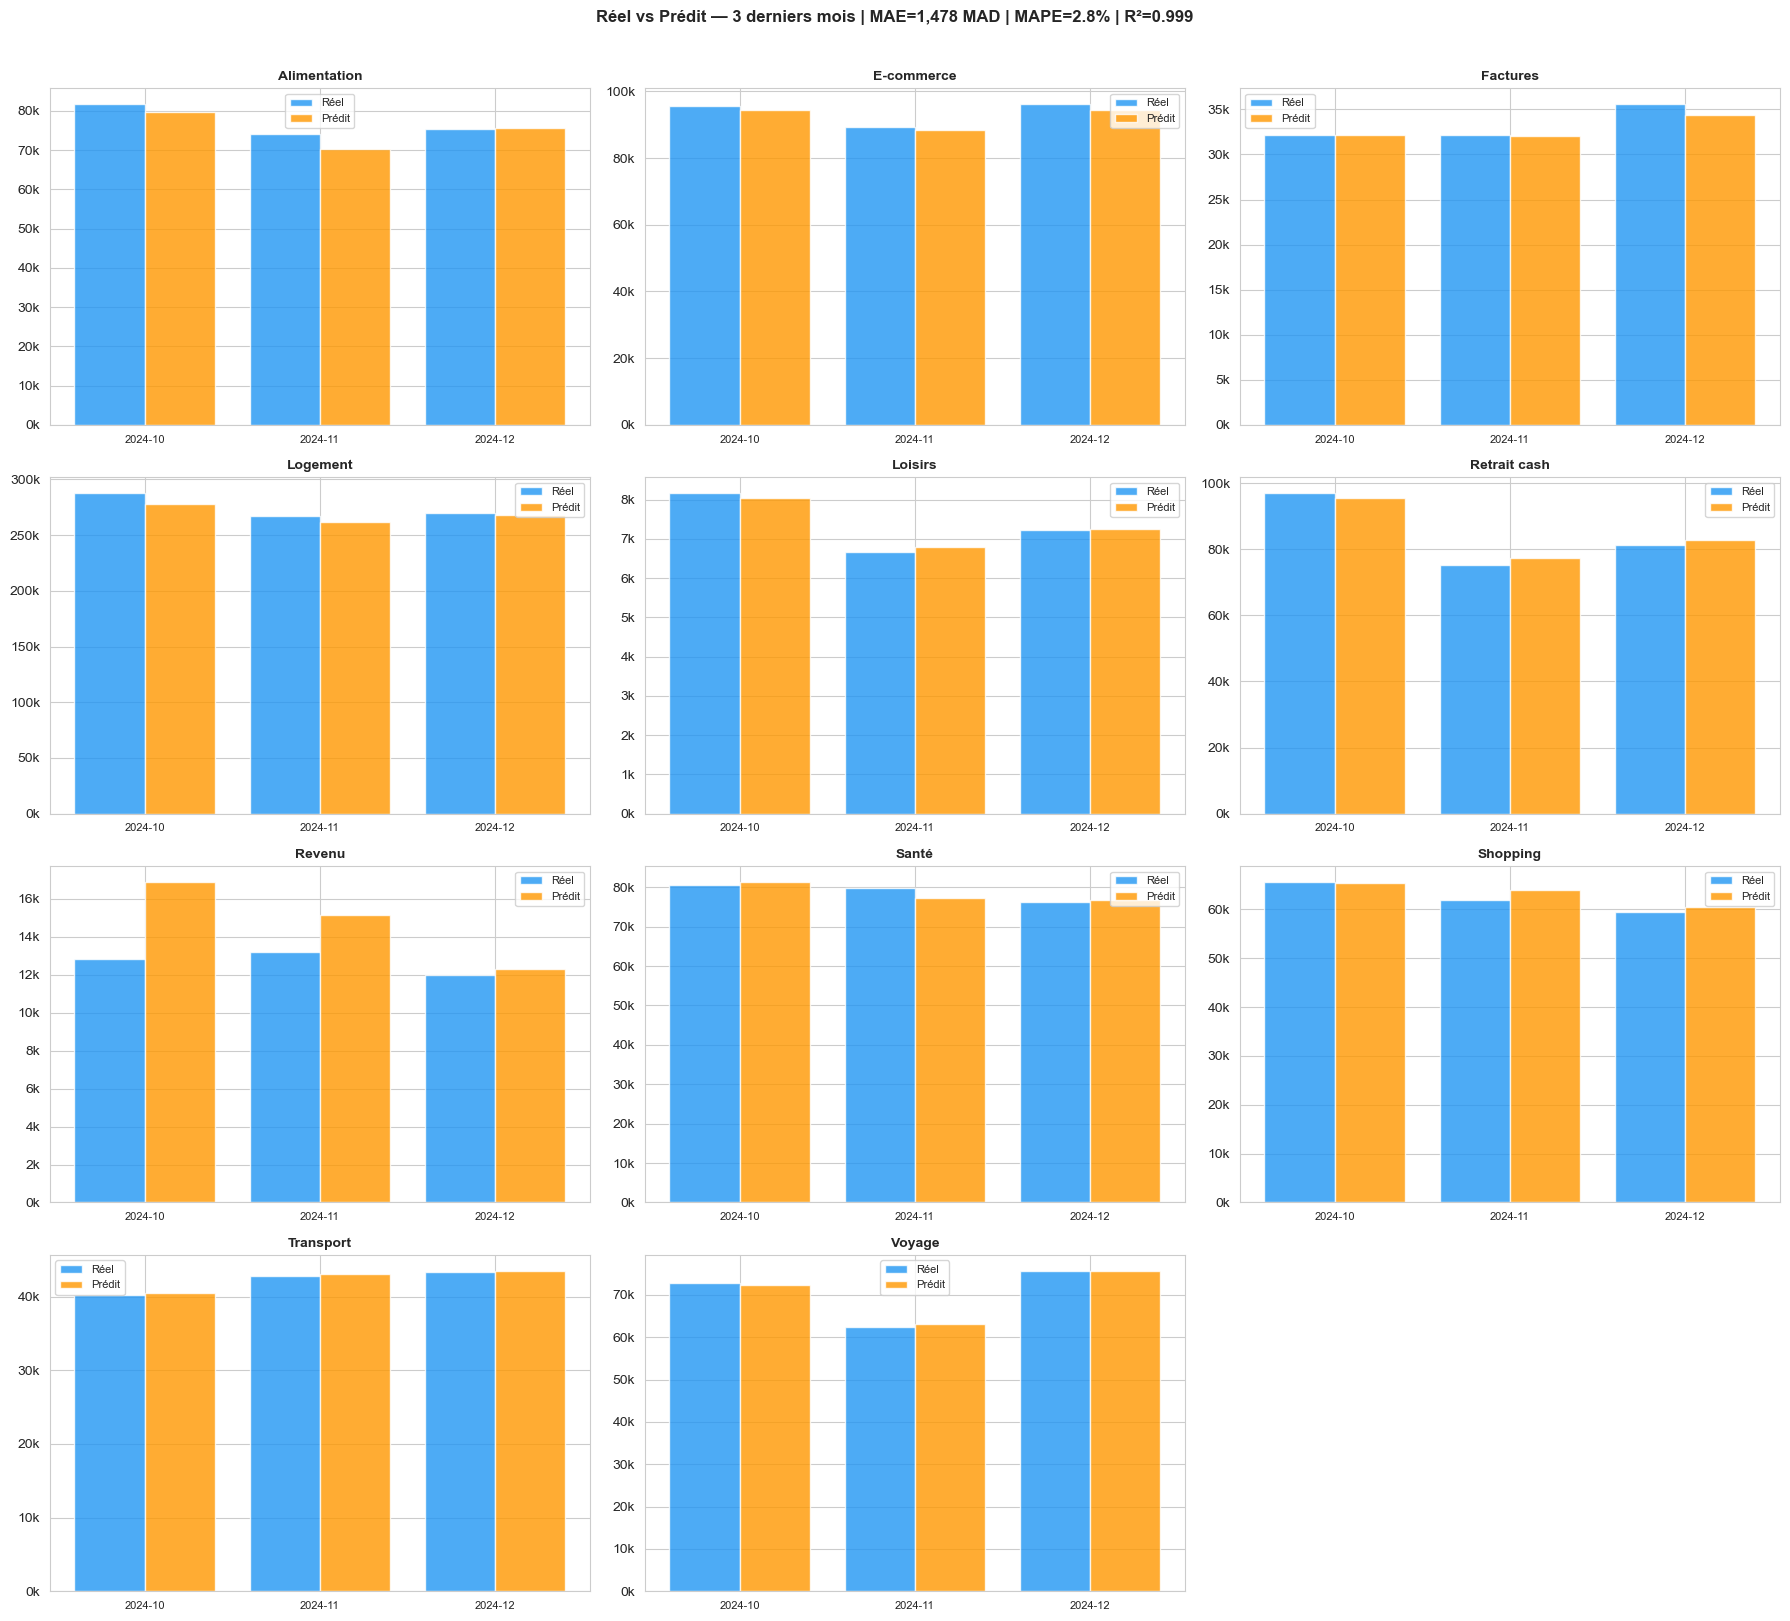

In [18]:
categories = sorted(test_df['category'].unique())
ncols = 3
nrows = (len(categories) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, cat in enumerate(categories):
    cat_df = test_df[test_df['category'] == cat].sort_values('period')
    ax = axes[i]
    x = range(len(cat_df))
    ax.bar([xi - 0.2 for xi in x], cat_df['total_amount'], width=0.4, label='Réel',  color='#2196F3', alpha=0.8)
    ax.bar([xi + 0.2 for xi in x], cat_df['predicted'],    width=0.4, label='Prédit', color='#FF9800', alpha=0.8)
    ax.set_xticks(list(x))
    ax.set_xticklabels([str(p) for p in cat_df['period']], fontsize=8)
    ax.set_title(cat, fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Réel vs Prédit — 3 derniers mois | MAE={mae:,.0f} MAD | MAPE={mape:.1f}% | R²={r2:.3f}',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(MODELS_STORE / 'prediction_actual_vs_predicted.png', dpi=100, bbox_inches='tight')
plt.show()

---
## Section 4 — Tableau Récapitulatif

In [19]:
summary = pd.DataFrame([
    {'Modèle': 'Classifieur catégories', 'Algorithme': 'TF-IDF + Régression Logistique',
     'Métrique': 'Accuracy', 'Score': f'{acc*100:.2f}%',
     'Statut': 'OK' if acc >= 0.80 else 'A ameliorer'},
    {'Modèle': 'Classifieur catégories', 'Algorithme': 'TF-IDF + Régression Logistique',
     'Métrique': 'F1 (weighted)', 'Score': f'{f1_w:.4f}', 'Statut': ''},
    {'Modèle': 'Classifieur catégories', 'Algorithme': 'TF-IDF + Régression Logistique',
     'Métrique': 'F1 (macro)', 'Score': f'{f1_m:.4f}', 'Statut': ''},
    {'Modèle': 'Détecteur anomalies', 'Algorithme': 'Isolation Forest (contamination=5%)',
     'Métrique': 'Anomalies détectées', 'Score': f'{n_anom:,} ({n_anom/len(debits)*100:.2f}%)',
     'Statut': 'OK'},
    {'Modèle': 'Prédicteur dépenses', 'Algorithme': 'Random Forest (200 arbres)',
     'Métrique': 'MAPE (holdout)', 'Score': f'{mape:.1f}%',
     'Statut': 'OK' if mape < 30 else 'A ameliorer'},
    {'Modèle': 'Prédicteur dépenses', 'Algorithme': 'Random Forest (200 arbres)',
     'Métrique': 'R2', 'Score': f'{r2:.4f}', 'Statut': ''},
])

print('=' * 80)
print('  BILAN — PERFORMANCE DES MODÈLES ML — BankAnalyzer')
print('=' * 80)
print(summary.to_string(index=False))
print('=' * 80)
print(f'\nCritère principal: Accuracy classifieur >= 80% → {"ATTEINT" if acc >= 0.80 else "NON ATTEINT"} ({acc*100:.2f}%)')

  BILAN — PERFORMANCE DES MODÈLES ML — BankAnalyzer
                Modèle                          Algorithme            Métrique         Score Statut
Classifieur catégories      TF-IDF + Régression Logistique            Accuracy       100.00%     OK
Classifieur catégories      TF-IDF + Régression Logistique       F1 (weighted)        1.0000       
Classifieur catégories      TF-IDF + Régression Logistique          F1 (macro)        1.0000       
   Détecteur anomalies Isolation Forest (contamination=5%) Anomalies détectées 2,281 (5.00%)     OK
   Prédicteur dépenses          Random Forest (200 arbres)      MAPE (holdout)          2.8%     OK
   Prédicteur dépenses          Random Forest (200 arbres)                  R2        0.9988       

Critère principal: Accuracy classifieur >= 80% → ATTEINT (100.00%)
